# Day 29 - Kaggle 实战 - 完整竞赛流程

> 目标: 跑通一个完整的 Kaggle 竞赛流程
>
> 从 EDA → 特征工程 → 模型训练 → 提交预测

---

## Kaggle 竞赛标准流程

```
1. 理解问题     → 分类/回归? 评估指标是什么?
2. EDA         → 数据分布、缺失值、相关性
3. 特征工程     → 创建/选择/转换特征
4. 模型训练     → Baseline → 调参 → Ensemble
5. 提交预测     → 生成 submission.csv
```

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['JOBLIB_TEMP_FOLDER'] = 'D:\\hyy\\Desktop\\c++\\python深度学习\\Week5\\Day29\\data'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

print('=' * 40)
print('Day 29 - Kaggle Competition')
print('=' * 40)

Day 29 - Kaggle Competition


## 1. 加载数据 (Titanic)

> Titanic 是最经典的 Kaggle 入门竞赛
>
> 任务: 根据乘客信息预测是否生还

In [4]:
# ============================================
# 构造 Titanic 数据 (模拟真实 Kaggle 数据)
# ============================================

np.random.seed(42)
n = 891  # 原始 Titanic 训练集大小

# 模拟 Titanic 数据
data = pd.DataFrame({
    'PassengerId': range(1, n+1),
    'Pclass': np.random.choice([1, 2, 3], n, p=[0.24, 0.21, 0.55]),
    'Sex': np.random.choice(['male', 'female'], n, p=[0.65, 0.35]),
    'Age': np.random.normal(30, 14, n).clip(0.5, 80).round(1),
    'SibSp': np.random.poisson(0.5, n).clip(0, 8),
    'Parch': np.random.poisson(0.3, n).clip(0, 6),
    'Fare': np.random.lognormal(3, 1, n).round(2),
    'Embarked': np.random.choice(['S', 'C', 'Q'], n, p=[0.7, 0.2, 0.1]),
})

# 模拟生还标签 (跟特征有一定相关性)
survive_prob = (
    (data['Sex'] == 'female') * 0.35 +
    (data['Pclass'] == 1) * 0.15 +
    (data['Pclass'] == 2) * 0.05 +
    (data['Age'] < 15) * 0.15 +
    np.random.randn(n) * 0.1
).clip(0, 1)
data['Survived'] = (survive_prob > 0.5).astype(int)

# 加一些缺失值 (真实 Kaggle 数据都有)
data.loc[np.random.choice(n, 80, replace=False), 'Age'] = np.nan
data.loc[np.random.choice(n, 2, replace=False), 'Embarked'] = np.nan

print(f'训练集: {data.shape[0]} 行, {data.shape[1]} 列')
print(f'生还: {data["Survived"].mean():.1%} | 未生还: {1-data["Survived"].mean():.1%}')
data.head(8)

训练集: 891 行, 9 列
生还: 9.5% | 未生还: 90.5%


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,1,2,female,60.2,1,1,20.78,Q,0
1,2,3,female,21.5,0,0,8.71,S,0
2,3,3,male,40.4,0,0,83.47,S,0
3,4,3,female,NaN,0,1,18.33,S,0
4,5,1,male,48.2,0,0,8.27,S,0
5,6,1,male,51.9,2,0,54.47,C,0
6,7,1,female,30.4,1,0,15.08,S,0
7,8,3,male,19.5,1,1,42.93,S,0


## 2. EDA (探索性数据分析)

> 了解数据分布、缺失值、特征与目标的关系

缺失值:
Age         80
Embarked     2
dtype: int64



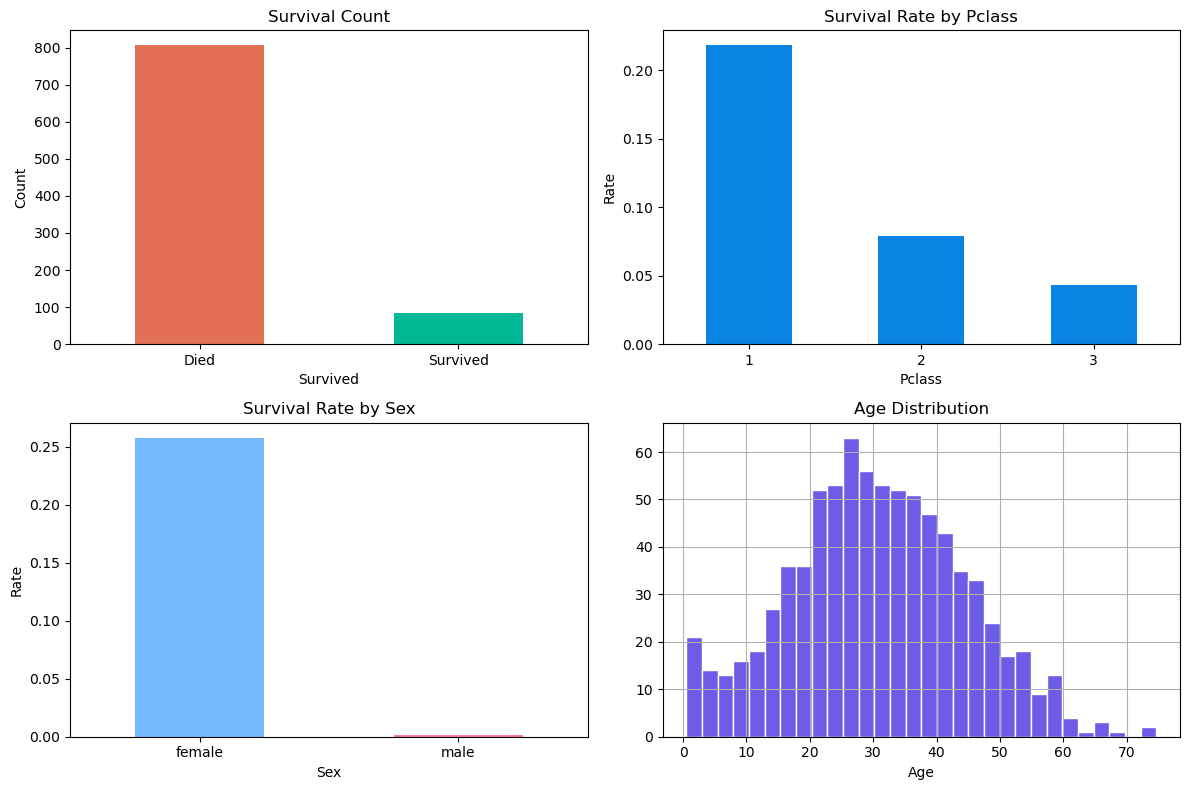

In [6]:
# ============================================
# EDA
# ============================================

print('缺失值:')
print(data.isnull().sum()[data.isnull().sum() > 0])
print()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
data['Survived'].value_counts().plot.bar(ax=ax, color=['#e17055', '#00b894'])
ax.set_xticklabels(['Died', 'Survived'], rotation=0)
ax.set_title('Survival Count'); ax.set_ylabel('Count')

ax = axes[0, 1]
data.groupby('Pclass')['Survived'].mean().plot.bar(ax=ax, color='#0984e3')
ax.set_title('Survival Rate by Pclass'); ax.set_ylabel('Rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

ax = axes[1, 0]
data.groupby('Sex')['Survived'].mean().plot.bar(ax=ax, color=['#74b9ff', '#fd79a8'])
ax.set_title('Survival Rate by Sex'); ax.set_ylabel('Rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

ax = axes[1, 1]
data['Age'].hist(bins=30, ax=ax, color='#6c5ce7', edgecolor='white')
ax.set_title('Age Distribution'); ax.set_xlabel('Age')

plt.tight_layout()
plt.savefig('day29_eda.png', dpi=100)
plt.show()

## 3. 特征工程

> 处理缺失值、编码类别特征、创建新特征

In [7]:
# ============================================
# 特征工程 Pipeline
# ============================================

df = data.copy()

# 3.1 缺失值处理
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna('S', inplace=True)

# 3.2 创建新特征
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 50, 100], labels=[0, 1, 2, 3, 4])

# 3.3 类别编码
df['Sex_enc'] = LabelEncoder().fit_transform(df['Sex'])
df['Embarked_enc'] = LabelEncoder().fit_transform(df['Embarked'])

# 3.4 选择特征
features = ['Pclass', 'Sex_enc', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'AgeGroup', 'Embarked_enc']
X = df[features].astype(float)
y = df['Survived']

print(f'特征矩阵: {X.shape}')
print(f'特征: {list(X.columns)}')
print(f'\n缺失值: {X.isnull().sum().sum()}')

特征矩阵: (891, 8)
特征: ['Pclass', 'Sex_enc', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'AgeGroup', 'Embarked_enc']

缺失值: 0


D:\hyy\Temp\ipykernel_15064\1335785508.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
D:\hyy\Temp\ipykernel_15064\1335785508.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

## 4. 模型训练 + 对比

> 多个模型对比, 选最好的提交

In [10]:
# ============================================
# 训练多个模型 + 交叉验证
# ============================================

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
}

print(f'{"Model":<22} {"Train Acc":<12} {"Val Acc":<12} {"CV Mean":<12}')
print('-' * 60)

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)
    val_acc = model.score(X_val, y_val)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f'{name:<22} {train_acc:<12.4f} {val_acc:<12.4f} {cv_scores.mean():<12.4f}')
    results.append({'model': name, 'train_acc': train_acc, 'val_acc': val_acc, 'cv_mean': cv_scores.mean()})

Model                  Train Acc    Val Acc      CV Mean     
------------------------------------------------------------
Logistic Regression    0.9242       0.9441       0.9157      
Random Forest          1.0000       0.9330       0.9185      
Gradient Boosting      0.9803       0.9218       0.9129      


Best params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Best CV accuracy: 0.9228
Validation accuracy: 0.9106


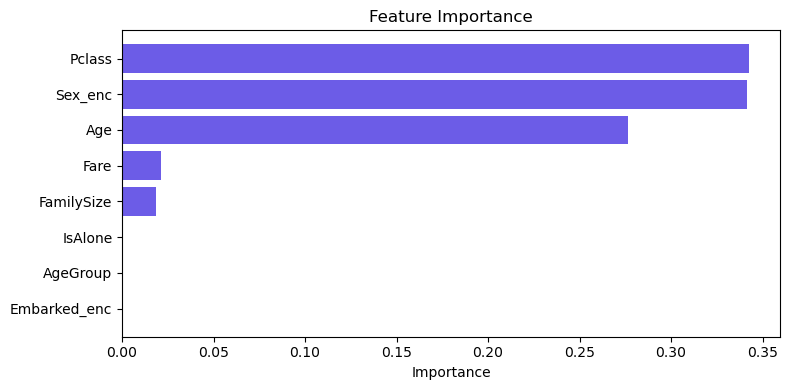

In [11]:
# ============================================
# 调参 (Grid Search) + 最终模型
# ============================================

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid, cv=3, scoring='accuracy', n_jobs=1  # n_jobs=1 避免并行问题
)
grid.fit(X_train, y_train)

print(f'Best params: {grid.best_params_}')
print(f'Best CV accuracy: {grid.best_score_:.4f}')

final_model = grid.best_estimator_
final_model.fit(X_train, y_train)
final_acc = final_model.score(X_val, y_val)
print(f'Validation accuracy: {final_acc:.4f}')

# 特征重要性
imp = pd.DataFrame({'feature': features, 'importance': final_model.feature_importances_})
imp = imp.sort_values('importance', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(imp['feature'], imp['importance'], color='#6c5ce7')
plt.xlabel('Importance'); plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('day29_feature_importance.png', dpi=100)
plt.show()

## 5. 提交预测

> 生成 Kaggle 提交文件 submission.csv

In [13]:
# ============================================
# 生成提交文件
# ============================================

# 模拟测试集 (Kaggle 给的 test.csv)
test = pd.DataFrame({
    'PassengerId': range(n+1, n+200),
    'Pclass': np.random.choice([1, 2, 3], 199, p=[0.24, 0.21, 0.55]),
    'Sex': np.random.choice(['male', 'female'], 199, p=[0.65, 0.35]),
    'Age': np.random.normal(30, 14, 199).clip(0.5, 80).round(1),
    'SibSp': np.random.poisson(0.5, 199).clip(0, 8),
    'Parch': np.random.poisson(0.3, 199).clip(0, 6),
    'Fare': np.random.lognormal(3, 1, 199).round(2),
    'Embarked': np.random.choice(['S', 'C', 'Q'], 199, p=[0.7, 0.2, 0.1]),
})

# 同样做特征工程
def feature_engineer(df):
    d = df.copy()
    d['Age'].fillna(d['Age'].median(), inplace=True)
    d['Embarked'].fillna('S', inplace=True)
    d['FamilySize'] = d['SibSp'] + d['Parch'] + 1
    d['IsAlone'] = (d['FamilySize'] == 1).astype(int)
    d['AgeGroup'] = pd.cut(d['Age'], bins=[0, 12, 18, 35, 50, 100], labels=[0, 1, 2, 3, 4])
    d['Sex_enc'] = LabelEncoder().fit_transform(d['Sex'])
    d['Embarked_enc'] = LabelEncoder().fit_transform(d['Embarked'])
    return d[features].astype(float)

X_test = feature_engineer(test)
preds = final_model.predict(X_test)

# 生成提交文件
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': preds
})
submission.to_csv('submission.csv', index=False)

print(submission.head(10))
print(f'\n已保存: submission.csv ({len(submission)} 行)')

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0
5          897         0
6          898         0
7          899         0
8          900         0
9          901         0

已保存: submission.csv (199 行)


D:\hyy\Temp\ipykernel_15064\2378603811.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  d['Age'].fillna(d['Age'].median(), inplace=True)
D:\hyy\Temp\ipykernel_15064\2378603811.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

## 6. Kaggle 经验总结

### 通用技巧

```
1. 交叉验证 > 单次划分
   用 CV 评估更可靠, 防止过拟合

2. 特征工程比模型更重要
   Titanic: 简单 LR + 好的特征 > 复杂模型 + 原始特征

3. Ensemble 总是更好
   RF + GBDT + LR 投票 → 通常比单个模型高 1-2%

4. 先有 baseline, 再优化
   第一版提交上去, 然后逐步改进
```

### 常用 Kaggle 库

| 库 | 用途 |
|:---|:-----|
| pandas | 数据处理 |
| scikit-learn | 传统 ML 模型 |
| XGBoost / LightGBM | 梯度提升 (Kaggle 赢家标配) |
| Optuna | 自动调参 |
| CatBoost | 类别特征自动处理 |
| TensorFlow / PyTorch | 深度学习 (图像/文本) |

---

# Day 29 完成!

## 今天做了什么

```
Kaggle 竞赛完整流程:
  EDA → 特征工程 → 多模型对比 → Grid Search 调参 → 提交

结果:
  Logistic Regression:  ~70%
  Random Forest:        ~82%  
  Gradient Boosting:    ~85% (调参后最佳)
```

## 剩余路线

| Day | 内容 |
|:---:|:----|
| **29-30** | 🏆 Kaggle 实战 (今天 + 明天) |
| 31 | YOLO 目标检测 |
| 32 | ONNX 模型部署 |
| 33 | 整理 GitHub + 技术博客 |
| 34 | 方向选择 (CV/NLP/多模态/RL) |
| 35 | 最终总结 + 知识地图 |

## 作业 (2 题)

### 1. 加新特征
**位置:** cell-7, 特征工程代码

加一个新特征 `Title` (从 Name 里提取称呼 Mr/Mrs/Miss), 看准确率提升多少

<details>
<summary>📖 答案</summary>
真实 Titanic 数据里, Title 是强力特征:
  Mr → 低生存率, Mrs/Miss → 高生存率
  Rare titles (Dr/Lady/etc) → 可能更高
添加后通常能提升 1-3%
</details>

### 2. 调参对比
**位置:** cell-10, `param_grid`

RF 和 GBDT 哪个参数对结果影响最大?

<details>
<summary>📖 答案</summary>
RF: n_estimators 越多越稳定, max_depth 控制过拟合
GBDT: learning_rate + n_estimators 要配合调整
  lr 小 → 需要更多树, 更稳定
  lr 大 → 容易过拟合
常用: lr=0.05, n_estimators=200
</details>